DenseNet Standalone Model

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_11020.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_11354.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_11348.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_10964.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_10305.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_11484.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_9742.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_9934.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_10505.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/realfake/fake/validation_10993.jpg
/kaggle/input/deepfake-dataset/deepfake_dataset/validation/rea

In [ ]:
#!/usr/bin/env python
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import logging
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

##############################################
#         Advanced Data Augmentation         #
##############################################
from albumentations import (
    HorizontalFlip, VerticalFlip, ShiftScaleRotate, CLAHE,
    RandomRotate90, Transpose, HueSaturationValue, GaussNoise,
    Sharpen, Emboss, RandomBrightnessContrast, OneOf, Compose, RandomCrop
)
from albumentations.pytorch import ToTensorV2
from PIL import Image

def strong_aug(p=0.5):
    return Compose([
        RandomRotate90(p=0.2),
        Transpose(p=0.2),
        HorizontalFlip(p=0.5),
        VerticalFlip(p=0.5),
        OneOf([GaussNoise()], p=0.2),
        ShiftScaleRotate(p=0.2),
        OneOf([
            CLAHE(clip_limit=2),
            Sharpen(),
            Emboss(),
            RandomBrightnessContrast(),
        ], p=0.2),
        HueSaturationValue(p=0.2),
        RandomCrop(width=200, height=200, p=0.3),
    ], p=p)

def augment(aug, image):
    return aug(image=image)["image"]

class Aug(object):
    def __call__(self, img):
        aug_inst = strong_aug(p=0.9)
        img_np = np.array(img)
        augmented = augment(aug_inst, img_np)
        return Image.fromarray(augmented)

##############################################
#            Data Transforms                 #
##############################################
def get_transforms():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return {
        "train": transforms.Compose([
            Aug(),                            
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.2)
        ]),
        "valid": transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        "test": transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    }

data_transforms = get_transforms()

##############################################
#            Dataset Loading                 #
##############################################
base_dataset_dir = "/kaggle/input/deepfake-dataset/deepfake_dataset"
sub_datasets = ["celebdf", "dfdc", "ffpp", "realfake"]

train_datasets = []
val_datasets = []
test_datasets = []

for sub in sub_datasets:
    train_path = os.path.join(base_dataset_dir, "train", sub)
    val_path   = os.path.join(base_dataset_dir, "validation", sub)
    test_path  = os.path.join(base_dataset_dir, "test", sub)

    train_datasets.append(datasets.ImageFolder(train_path, transform=data_transforms["train"]))
    val_datasets.append(datasets.ImageFolder(val_path, transform=data_transforms["valid"]))
    test_datasets.append(datasets.ImageFolder(test_path, transform=data_transforms["test"]))

full_train_dataset = ConcatDataset(train_datasets)
full_val_dataset   = ConcatDataset(val_datasets)
full_test_dataset  = ConcatDataset(test_datasets)

train_subset_size = 20000
val_subset_size = 5000
train_indices = random.sample(range(len(full_train_dataset)), train_subset_size)
val_indices = random.sample(range(len(full_val_dataset)), val_subset_size)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset   = Subset(full_val_dataset, val_indices)
test_dataset  = full_test_dataset

batch_size = 16
num_workers = 2

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

##############################################
#        Simple DenseNet161 Detector Model   #
##############################################
class SimpleDenseNetDetector(nn.Module):
    def __init__(self, num_classes=1):
        super(SimpleDenseNetDetector, self).__init__()
        self.backbone = timm.create_model('densenet161', pretrained=True, num_classes=0)
        self.classifier = nn.Sequential(
            nn.Linear(2208, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.classifier(features)
        return out

model = SimpleDenseNetDetector(num_classes=1)
model = model.to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel.")
    model = nn.DataParallel(model)
print("Simple DenseNet161 Detector created.")

##############################################
#        Optimizer & Loss Setup              #
##############################################
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

##############################################
#            Training & Validation           #
##############################################
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training")
    for images, labels in train_bar:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).int()
        train_correct += (preds.cpu() == labels.cpu().int()).sum().item()
        train_total += labels.size(0)
        current_loss = running_loss / train_total
        current_acc = train_correct / train_total
        train_bar.set_postfix(loss=f"{current_loss:.4f}", acc=f"{current_acc:.4f}")

    train_loss = running_loss / train_total
    train_acc = train_correct / train_total

    model.eval()
    running_loss_val = 0.0
    val_correct = 0
    val_total = 0
    for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss_val += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).int()
        val_correct += (preds.cpu() == labels.cpu().int()).sum().item()
        val_total += labels.size(0)
    val_loss = running_loss_val / val_total
    val_acc = val_correct / val_total

    print(f"\nEpoch [{epoch+1}/{num_epochs}] Summary:")
    print(f"  Training Loss: {train_loss:.4f}, Training Accuracy: {train_acc:.4f}")
    print(f"  Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

##############################################
#                Testing                     #
##############################################


model.eval()
running_loss_test = 0.0
test_correct = 0
test_total = 0
all_preds = []
all_labels = []
all_probs = []  

for images, labels in tqdm(test_loader, desc="Testing"):
    images = images.to(device)
    labels = labels.float().unsqueeze(1).to(device)
    outputs = model(images)
    loss = criterion(outputs, labels)
    running_loss_test += loss.item() * images.size(0)

    probs = torch.sigmoid(outputs)  
    all_probs.extend(probs.cpu().detach().numpy().flatten())

    preds = (probs > 0.5).int()
    all_preds.extend(preds.cpu().numpy().flatten())
    all_labels.extend(labels.cpu().numpy().flatten())
    test_correct += (preds.cpu() == labels.cpu().int()).sum().item()
    test_total += labels.size(0)

test_loss = running_loss_test / test_total
test_acc = test_correct / test_total

conf_mat = confusion_matrix(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = auc(*roc_curve(all_labels, all_probs)[:2])  # Compute AUC

print("\n=== Test Evaluation Metrics ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_mat)

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Using device: cuda


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


model.safetensors:   0%|          | 0.00/116M [00:00<?, ?B/s]

Using 2 GPUs with DataParallel.
Simple DenseNet161 Detector created.


Epoch 1/15 - Validation: 100%|██████████| 313/313 [01:07<00:00,  4.67it/s]


...

Epoch 13/15 - Validation: 100%|██████████| 313/313 [01:04<00:00,  4.83it/s]



Epoch [13/15] Summary:
  Training Loss: 0.2975, Training Accuracy: 0.8686
  Validation Loss: 0.2744, Validation Accuracy: 0.8896


Epoch 14/15 - Validation: 100%|██████████| 313/313 [01:05<00:00,  4.81it/s]



Epoch [14/15] Summary:
  Training Loss: 0.2888, Training Accuracy: 0.8726
  Validation Loss: 0.2597, Validation Accuracy: 0.8930


Epoch 15/15 - Training:  16%|█▌        | 203/1250 [01:18<06:27,  2.70it/s, acc=0.8741, loss=0.2914]

Testing: 100%|██████████| 522/522 [01:46<00:00,  4.88it/s]



=== Test Evaluation Metrics ===
Test Loss: 0.2725
Test Accuracy: 0.8788
Precision: 0.9175
Recall: 0.8121
F1 Score: 0.8616
AUC: 0.9588
Confusion Matrix:
[[4187  283]
 [ 728 3146]]


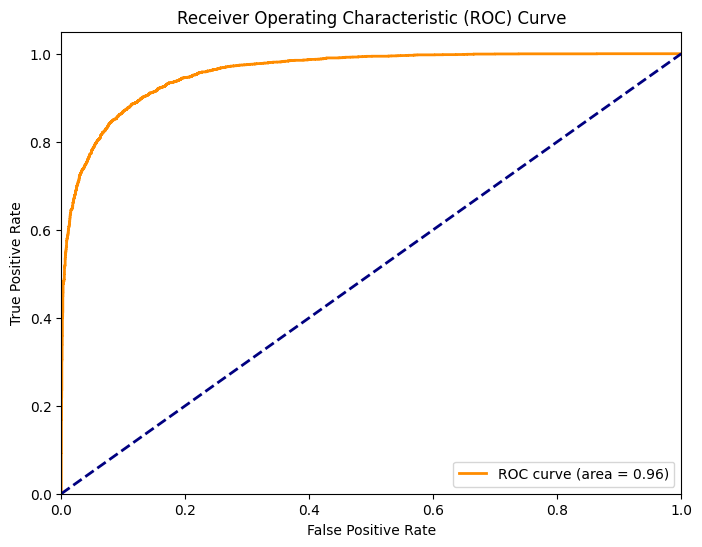

In [ ]:
model.eval()
running_loss_test = 0.0
test_correct = 0
test_total = 0
all_preds = []
all_labels = []
all_probs = []  

for images, labels in tqdm(test_loader, desc="Testing"):
    images = images.to(device)
    labels = labels.float().unsqueeze(1).to(device)
    outputs = model(images)
    loss = criterion(outputs, labels)
    running_loss_test += loss.item() * images.size(0)

    probs = torch.sigmoid(outputs)  
    all_probs.extend(probs.cpu().detach().numpy().flatten())

    preds = (probs > 0.5).int()
    all_preds.extend(preds.cpu().numpy().flatten())
    all_labels.extend(labels.cpu().numpy().flatten())
    test_correct += (preds.cpu() == labels.cpu().int()).sum().item()
    test_total += labels.size(0)

test_loss = running_loss_test / test_total
test_acc = test_correct / test_total

conf_mat = confusion_matrix(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = auc(*roc_curve(all_labels, all_probs)[:2])  

print("\n=== Test Evaluation Metrics ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_mat)

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()